In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython import display

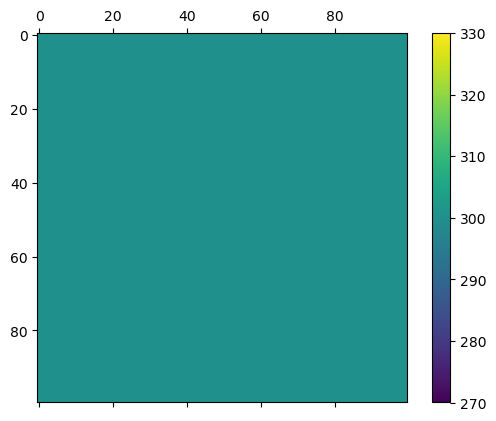

In [36]:
N=100
t0=300 #Kelvin
alpha1 = 1.0
alpha2 = 5

#xmin, xmax = 0,1
#ymin, ymax = 0,1
#x = np.linspace(xmin, xmax,N)
#y = np.linspace(ymin, ymax, N)

#dx = x[1] - x[0]
#dy = y[1] - y[0]
#dt = 0.2*dx**2/(4*alpha)

dx =1
dt = 0.01

max_iter = 5000
tol = 1e-5


T=t0*np.ones((N,N))

fig,ax = plt.subplots()
mat = ax.matshow(T)
fig.colorbar(mat)

In [29]:
#shift = 1, axis = 0: moved down
#shift = -1, axis = 0: moved up
#shift = 1, axis = 1: moved to the right
#shift = -1, axis = 1: moved to the left

In [30]:
T_top = np.roll(T, shift =1, axis = 0)
T_bottom = np.roll(T, shift =-1, axis = 0)
T_left = np.roll(T, shift =1, axis = 1)
T_right = np.roll(T, shift =-1, axis = 1)

grad_T = (T_top + T_bottom + T_left + T_right -4*T)/(dx**2)

In [31]:
def boundary_con(arr, case):
    if case == 'a':
        arr[0,:] = 1000 #Kelvin #top
        arr[-1,:] = 1000 #Kelvin  #bottom
        arr[:,0] = 1000 #Kelvin #left
        arr[:,-1] = 1000 #Kelvin  #right

    if case == 'b':
        arr[0,:] = 100 #Kelvin #top
        arr[-1,:] = 100 #Kelvin #bottom
        arr[:,0] = 100 #Kelvin #left
        arr[:,-1] = 100 #Kelvin #right
        
    if case == 'c':
        arr[0,:] = 100 #Kelvin #top
        arr[-1,:] = 100 #Kelvin #bottom
        arr[:,0] = 1000 #Kelvin #left
        arr[:,-1] = 1000 #Kelvin #right
        
    if case == 'd':
        arr[0,:] = 1000 #Kelvin #top
        arr[-1,:] = arr[-2,:] #insulating #bottom
        arr[:,0] = arr[:,1] #insulating #left
        arr[:,-1] = arr[:,-2] #insulating #right
        
    return arr

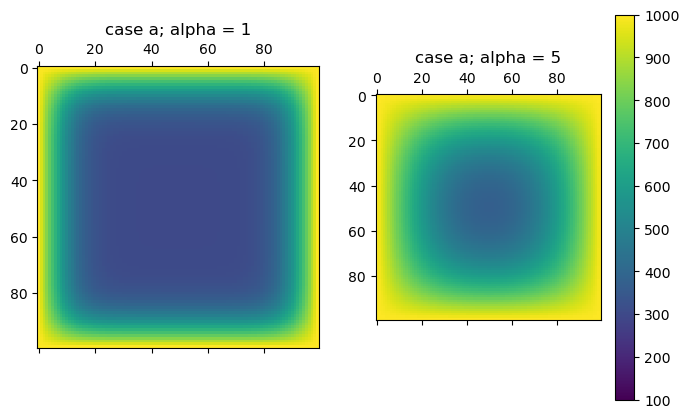

In [52]:
T1_evol = []
T1 = t0*np.ones((N,N))

for i in range(max_iter):
    #T = boundary_con(T,'a')

    T_top = np.roll(T1, shift =1, axis = 0)
    T_bottom = np.roll(T1, shift =-1, axis = 0)
    T_left = np.roll(T1, shift =1, axis = 1)
    T_right = np.roll(T1, shift =-1, axis = 1)

    grad_T1 = alpha1*(T_top + T_bottom + T_left + T_right -(4*T1))/(dx**2)
    forward_time = T1+dt*(grad_T1)

    forward_time = boundary_con(forward_time,'a')

    T1 = forward_time

    T1_evol.append(T)

T2_evol = []
T2 = t0*np.ones((N,N))

for i in range(max_iter):
    #T = boundary_con(T,'a')

    T_top = np.roll(T2, shift =1, axis = 0)
    T_bottom = np.roll(T2, shift =-1, axis = 0)
    T_left = np.roll(T2, shift =1, axis = 1)
    T_right = np.roll(T2, shift =-1, axis = 1)

    grad_T2 = alpha2*(T_top + T_bottom + T_left + T_right -(4*T2))/(dx**2)
    forward_time = T2+dt*(grad_T2)

    forward_time = boundary_con(forward_time,'a')

    T2 = forward_time

    T2_evol.append(T)

fig,axs = plt. subplots(1,2, figsize = (8,5))
#ax.set_title("case a; alpha = 1")
axs[0].matshow(T1, vmin = 100, vmax = 1000)
axs[0].set_title("case a; alpha = 1")
o = axs[1].matshow(T2, vmin = 100, vmax = 1000)
axs[1].set_title("case a; alpha = 5")
fig.colorbar(o)
#fig.tight_layout()
plt.savefig("PDEa")

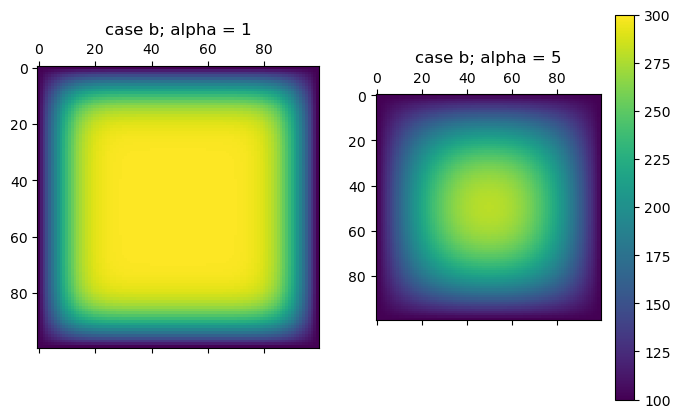

In [53]:
T1_evol = []
T1 = t0*np.ones((N,N))

for i in range(max_iter):
    #T = boundary_con(T,'b')

    T_top = np.roll(T1, shift =1, axis = 0)
    T_bottom = np.roll(T1, shift =-1, axis = 0)
    T_left = np.roll(T1, shift =1, axis = 1)
    T_right = np.roll(T1, shift =-1, axis = 1)

    grad_T1 = alpha1*(T_top + T_bottom + T_left + T_right -(4*T1))/(dx**2)
    forward_time = T1+dt*(grad_T1)

    forward_time = boundary_con(forward_time,'b')

    T1 = forward_time

    T1_evol.append(T)

T2_evol = []
T2 = t0*np.ones((N,N))

for i in range(max_iter):
    #T = boundary_con(T,'b')

    T_top = np.roll(T2, shift =1, axis = 0)
    T_bottom = np.roll(T2, shift =-1, axis = 0)
    T_left = np.roll(T2, shift =1, axis = 1)
    T_right = np.roll(T2, shift =-1, axis = 1)

    grad_T2 = alpha2*(T_top + T_bottom + T_left + T_right -(4*T2))/(dx**2)
    forward_time = T2+dt*(grad_T2)

    forward_time = boundary_con(forward_time,'b')

    T2 = forward_time

    T2_evol.append(T)

fig,axs = plt. subplots(1,2, figsize = (8,5))
#ax.set_title("case b = all boundaries are 100K")
axs[0].matshow(T1, vmin = 100, vmax = 300)
axs[0].set_title("case b; alpha = 1")
o = axs[1].matshow(T2, vmin = 100, vmax = 300)
axs[1].set_title("case b; alpha = 5")
fig.colorbar(o)
plt.savefig("PDEb")

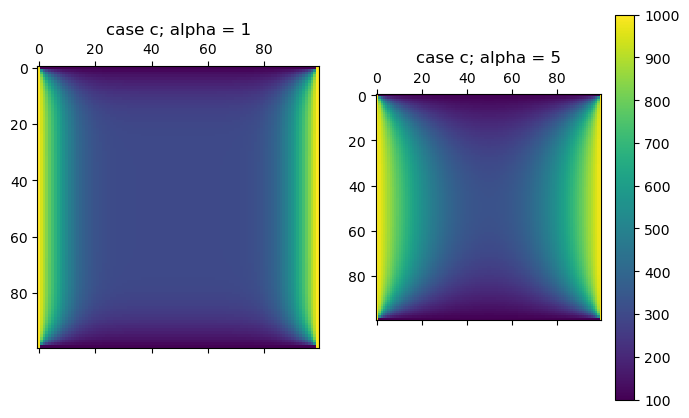

In [54]:
T1_evol = []
T1 = t0*np.ones((N,N))

for i in range(max_iter):
    #T = boundary_con(T,'b')

    T_top = np.roll(T1, shift =1, axis = 0)
    T_bottom = np.roll(T1, shift =-1, axis = 0)
    T_left = np.roll(T1, shift =1, axis = 1)
    T_right = np.roll(T1, shift =-1, axis = 1)

    grad_T1 = alpha1*(T_top + T_bottom + T_left + T_right -(4*T1))/(dx**2)
    forward_time = T1+dt*(grad_T1)

    forward_time = boundary_con(forward_time,'c')

    T1 = forward_time

    T1_evol.append(T)

T2_evol = []
T2 = t0*np.ones((N,N))

for i in range(max_iter):
    #T = boundary_con(T,'b')

    T_top = np.roll(T2, shift =1, axis = 0)
    T_bottom = np.roll(T2, shift =-1, axis = 0)
    T_left = np.roll(T2, shift =1, axis = 1)
    T_right = np.roll(T2, shift =-1, axis = 1)

    grad_T2 = alpha2*(T_top + T_bottom + T_left + T_right -(4*T2))/(dx**2)
    forward_time = T2+dt*(grad_T2)

    forward_time = boundary_con(forward_time,'c')

    T2 = forward_time

    T2_evol.append(T)

fig,axs = plt. subplots(1,2, figsize = (8,5))
#ax.set_title("case c = top and bottom are 100K; left and right are 1000K")
axs[0].matshow(T1, vmin = 100, vmax = 1000)
axs[0].set_title("case c; alpha = 1")
o = axs[1].matshow(T2, vmin = 100, vmax = 1000)
axs[1].set_title("case c; alpha = 5")
fig.colorbar(o)
plt.savefig("PDEc")

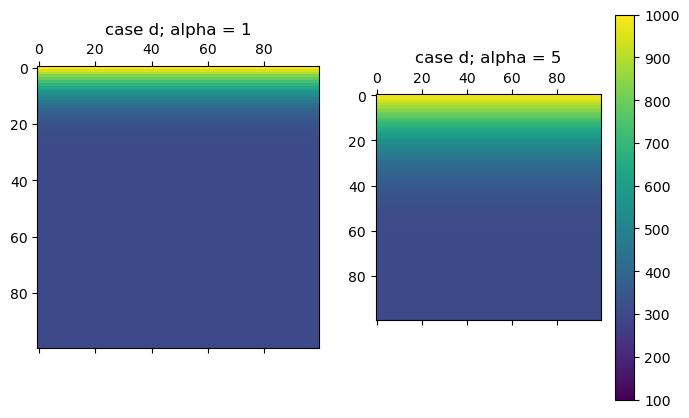

In [55]:
T1_evol = []
T1 = t0*np.ones((N,N))

for i in range(max_iter):
    #T = boundary_con(T,'b')

    T_top = np.roll(T1, shift =1, axis = 0)
    T_bottom = np.roll(T1, shift =-1, axis = 0)
    T_left = np.roll(T1, shift =1, axis = 1)
    T_right = np.roll(T1, shift =-1, axis = 1)

    grad_T1 = alpha1*(T_top + T_bottom + T_left + T_right -(4*T1))/(dx**2)
    forward_time = T1+dt*(grad_T1)

    forward_time = boundary_con(forward_time,'d')

    T1 = forward_time

    T1_evol.append(T)

T2_evol = []
T2 = t0*np.ones((N,N))

for i in range(max_iter):
    #T = boundary_con(T,'b')

    T_top = np.roll(T2, shift =1, axis = 0)
    T_bottom = np.roll(T2, shift =-1, axis = 0)
    T_left = np.roll(T2, shift =1, axis = 1)
    T_right = np.roll(T2, shift =-1, axis = 1)

    grad_T2 = alpha2*(T_top + T_bottom + T_left + T_right -(4*T2))/(dx**2)
    forward_time = T2+dt*(grad_T2)

    forward_time = boundary_con(forward_time,'d')

    T2 = forward_time

    T2_evol.append(T)

fig,axs = plt. subplots(1,2, figsize = (8,5))
#ax.set_title("case d = top is set at 1000K; others are insulating")
axs[0].matshow(T1, vmin = 100, vmax = 1000)
axs[0].set_title("case d; alpha = 1")
o = axs[1].matshow(T2, vmin = 100, vmax = 1000)
axs[1].set_title("case d; alpha = 5")
fig.colorbar(o)
plt.savefig("PDEd")